# Graph Semantic Clustering

In [2]:
# Import Libraries
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import string
import os
import warnings
import heapq
import re
import nltk
from collections import Counter, defaultdict
from nltk.corpus import stopwords
from itertools import combinations
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans, SpectralClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [3]:
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\snand\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\snand\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\snand\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### 1. Prepare the Text Data

In [5]:
# List of file paths for the books
book_files = ["metamorphosis.txt", "gatsby.txt", "mrs_dalloway.txt", "little_women.txt"]

In [6]:
# Function to read and clean text
def read_and_clean(file_path):
    with open(file_path, "r", encoding = "utf-8") as f:
        text = f.read()
    # Remove Gutenberg headers and footers (basic cleanup)
    text = re.sub(r"\*\*\* START OF.*?\*\*\*", "", text, flags = re.DOTALL)
    text = re.sub(r"\*\*\* END OF.*?\*\*\*", "", text, flags = re.DOTALL)
    # Remove excessive new-lines
    text = re.sub(r"\n+", "\n", text.strip())
    return text

# Folder paths
data_folder = "../data/"
output_folder = "../output/"

# Ensure output folder exists
os.makedirs(output_folder, exist_ok=True)

# Get all files from data folder
book_files = [f for f in os.listdir(data_folder) if f.endswith(".txt")]

# Read and clean all books
book_texts = {
    file: read_and_clean(os.path.join(data_folder, file))
    for file in book_files
}

# Concatenate all books with titles
combined_text = "\n\n".join(
    [f"### {file.upper()} ###\n\n" + text for file, text in book_texts.items()]
)

# Save the concatenated text to output folder
output_path = os.path.join(output_folder, "combined_books.txt")
with open(output_path, "w", encoding="utf-8") as f:
    f.write(combined_text)

print("Books loaded, cleaned, and concatenated successfully!")

Books loaded, cleaned, and concatenated successfully!


### 2. Select 100 Words

In [8]:
def extract_top_words(text, top_n = 100, word_classes = None):
    stop_words = set(stopwords.words('english')) # get list of english stopwords

    # Tokenize words
    words = nltk.word_tokenize(text)
    words = [word for word in words if word.isalpha() and word.lower() not in stop_words]
    
    # POS tagging
    tagged_words = nltk.pos_tag(words)

    # Default word classes to include if none are provided
    if word_classes is None:
        word_classes = ['NN', 'NNS', 'VB', 'VBD', 'JJ', 'RB']

    # Filtering: Keeping nouns, verbs, adjectives and adverbs
    filtered_words = [
        word.lower() for word, tag in tagged_words
        if tag.startswith(tuple(word_classes))
        and word.lower() not in stop_words
        and word not in string.punctuation
        and len(word) > 1
    ]

    # count word frequencies
    word_freq = Counter(filtered_words)

    # Get the top words
    top_words = [word for word, _ in word_freq.most_common(top_n)]
    return top_words

# Call the function
L = extract_top_words(combined_text)

print("Top 100 words: ", L)

Top 100 words:  ['said', 'jo', 'little', 'meg', 'amy', 'old', 'laurie', 'see', 'go', 'never', 'time', 'thought', 'good', 'came', 'made', 'much', 'come', 'mother', 'know', 'went', 'well', 'beth', 'looked', 'say', 'way', 'got', 'people', 'think', 'away', 'get', 'work', 'young', 'look', 'eyes', 'room', 'asked', 'make', 'something', 'man', 'face', 'day', 'project', 'things', 'home', 'always', 'going', 'back', 'long', 'march', 'felt', 'even', 'first', 'girls', 'gregor', 'let', 'father', 'hand', 'love', 'head', 'seemed', 'tell', 'put', 'door', 'life', 'quite', 'new', 'looking', 'great', 'nothing', 'take', 'house', 'dear', 'took', 'saw', 'clarissa', 'ever', 'lady', 'still', 'help', 'gatsby', 'miss', 'heart', 'knew', 'hands', 'began', 'anything', 'right', 'last', 'better', 'cried', 'rather', 'sat', 'want', 'daisy', 'full', 'thing', 'poor', 'found', 'told', 'voice']


### 3. Compute Word Similarities

In [10]:
# Function to compute similarity as a co-occurrence in a sentence (optimized version)
def compute_similarity_optimized(text, word_list):
    sentences = nltk.sent_tokenize(text)
    word_to_index = {word: idx for idx, word in enumerate(word_list)}
    word_pair_counts = defaultdict(int)
    
    # Iterate over all sentences
    for sent in sentences:
        # Get all words in the sentence that are in the word list
        words_in_sentence = set([word.lower() for word in nltk.word_tokenize(sent) if word.lower() in word_to_index])
        
        # Count co-occurrences for all pairs of words in the sentence
        for word1, word2 in combinations(words_in_sentence, 2):
            word_pair_counts[(word1, word2)] += 1

    # Build the similarity matrix
    similarity_matrix = np.zeros((len(word_list), len(word_list)))
    for (word1, word2), count in word_pair_counts.items():
        i = word_to_index[word1]
        j = word_to_index[word2]
        similarity_matrix[i][j] = similarity_matrix[j][i] = count

    return similarity_matrix

# Call the optimized function
similarity_matrix_optimized = compute_similarity_optimized(combined_text, L)

# Display a preview of the matrix (first 5x5 for checking)
print("Similarity Matrix: \n", similarity_matrix_optimized[:5, :5])


Similarity Matrix: 
 [[  0. 140.  22.   6.  88.]
 [140.   0.  52.  96.  48.]
 [ 22.  52.   0.   8.  14.]
 [  6.  96.   8.   0.   2.]
 [ 88.  48.  14.   2.   0.]]


In [11]:
# Creating a labeled DataFrame from the matrix
similarity_df = pd.DataFrame(similarity_matrix_optimized[:5, :5], 
                             index=L[:5], 
                             columns=L[:5]).astype(int)

# Display the DataFrame nicely
print("Optimized Similarity Matrix:")
print(similarity_df)

Optimized Similarity Matrix:
        said   jo  little  meg  amy
said       0  140      22    6   88
jo       140    0      52   96   48
little    22   52       0    8   14
meg        6   96       8    0    2
amy       88   48      14    2    0


In [12]:
# Count word frequencies
word_freq = Counter(L)

# Get top 10 most frequent words
top_10 = word_freq.most_common(10)

# Create a ranked DataFrame
ranked_df = pd.DataFrame(top_10, columns=['Word', 'Frequency'])
ranked_df.index += 1  # Rank starts at 1
ranked_df.reset_index(inplace=True)
ranked_df.columns = ['Rank', 'Word', 'Frequency']

# Display the table
print(ranked_df)

   Rank    Word  Frequency
0     1    said          1
1     2      jo          1
2     3  little          1
3     4     meg          1
4     5     amy          1
5     6     old          1
6     7  laurie          1
7     8     see          1
8     9      go          1
9    10   never          1


In [13]:
# Identifying the top 5 most and least similar word pairs (non-zero)
def get_top_and_bottom_pairs(similarity_matrix, word_list, top_n=5):
    pairs = []
    n = len(word_list)
    for i in range(n):
        for j in range(i+1, n):
            sim = similarity_matrix[i][j]
            pairs.append((sim, word_list[i], word_list[j]))
    
    # Filter out zero similarity (no co-occurrence)
    non_zero_pairs = [p for p in pairs if p[0] > 0]
    top_pairs = heapq.nlargest(top_n, non_zero_pairs)
    bottom_pairs = heapq.nsmallest(top_n, non_zero_pairs)
    
    return top_pairs, bottom_pairs

top, bottom = get_top_and_bottom_pairs(similarity_matrix_optimized, L)

print("\nTop 5 Most Similar Word Pairs (High Co-occurrence):")
for sim, w1, w2 in top:
    print(f"{w1} - {w2}: {sim:.1f}")

print("\nTop 5 Least Similar Word Pairs (Low but Non-Zero Co-occurrence):")
for sim, w1, w2 in bottom:
    print(f"{w1} - {w2}: {sim:.1f}")



Top 5 Most Similar Word Pairs (High Co-occurrence):
little - made: 150.0
work - project: 146.0
jo - face: 142.0
said - jo: 140.0
said - look: 138.0

Top 5 Least Similar Word Pairs (Low but Non-Zero Co-occurrence):
always - clarissa: 2.0
always - door: 2.0
always - going: 2.0
always - gregor: 2.0
always - house: 2.0


In [14]:
# Frequency of Co-occurence in the same sentence
def display_cooccurrence(text, word_list):
    sentences = nltk.sent_tokenize(text)
    word_to_index = {word: idx for idx, word in enumerate(word_list)}
    word_pair_counts = defaultdict(int)
    
    for sent in sentences:
        words_in_sentence = set(
            [word.lower() for word in nltk.word_tokenize(sent) if word.lower() in word_to_index]
        )
        for word1, word2 in combinations(words_in_sentence, 2):
            word_pair_counts[(word1, word2)] += 1
    
    # Display results
    cooccurrence_results = []
    for (word1, word2), count in word_pair_counts.items():
        cooccurrence_results.append(f"{word1}, {word2} = {count:.1f}")
    
    return cooccurrence_results

# Example Usage
cooccurrence_results = display_cooccurrence(combined_text, L)
print("\nFrequency of Co-occurrence Results:")
for result in cooccurrence_results[:10]:  # Display top 10 results
    print(result)


Frequency of Co-occurrence Results:
project, away = 16.0
gregor, found = 14.0
little, see = 80.0
little, head = 78.0
little, back = 78.0
see, head = 30.0
see, back = 42.0
head, back = 58.0
room, little = 70.0
sat, lady = 4.0


In [15]:
# Average Distance Apart in the text
def display_average_distance(text, word_list):
    words = nltk.word_tokenize(text)
    word_indices = {word: [] for word in word_list}

    for idx, word in enumerate(words):
        word_lower = word.lower()
        if word_lower in word_indices:
            word_indices[word_lower].append(idx)

    distance_results = []
    for i, word1 in enumerate(word_list):
        for j in range(i+1, len(word_list)):
            word2 = word_list[j]
            positions1 = word_indices[word1]
            positions2 = word_indices[word2]
            if positions1 and positions2:
                # Sampling to reduce complexity
                sample1 = positions1[:10]
                sample2 = positions2[:10]
                distances = [abs(p1 - p2) for p1 in sample1 for p2 in sample2]
                avg_distance = np.mean(distances) if distances else float('inf')
                distance_results.append(f"d({word1}, {word2}) = {avg_distance:.1f}")
    return distance_results

In [16]:
# Example
average_distance_results = display_average_distance(combined_text, L)
print("\nAverage Distance Apart Results:")
for result in average_distance_results[:10]:  # Display top 10 results
    print(result)


Average Distance Apart Results:
d(said, jo) = 171897.1
d(said, little) = 1493.2
d(said, meg) = 172382.7
d(said, amy) = 172350.3
d(said, old) = 10896.7
d(said, laurie) = 183331.2
d(said, see) = 1919.5
d(said, go) = 1926.4
d(said, never) = 4419.2
d(said, time) = 1429.4


### 4. Perform Unsupervised Learning

In [18]:
warnings.filterwarnings("ignore")
os.environ["OMP_NUM_THREADS"] = "1"

def evaluate_clustering_models(similarity_matrix, words, num_clusters = 5, eps = 0.5, min_samples = 2):
    # Convert similarity to distance (1/(similarity + 1e-10) to avoid division by 0)
    distance_matrix = 1 / (similarity_matrix + 1e-10)

    # Setting diagonal to 0 (no self-similarity)
    np.fill_diagonal(distance_matrix, 0)

    # Standardize the similarity matrix for feature-based clustering models (K-Means and Spectral)
    scaler = StandardScaler()
    similarity_scaled = scaler.fit_transform(similarity_matrix)

    silhouette_scoring = {}

    # Agglomerative Clustering
    agg_clustering = AgglomerativeClustering(n_clusters=num_clusters, metric="precomputed", linkage="average")
    agg_labels = agg_clustering.fit_predict(distance_matrix)
    silhouette_scoring["Agglomerative"] = silhouette_score(distance_matrix, agg_labels, metric="precomputed")

    # DBSCAN Clustering
    dbscan_clustering = DBSCAN(metric="precomputed", eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan_clustering.fit_predict(distance_matrix)
    if len(set(dbscan_labels)) > 1:
        silhouette_scoring["DBSCAN"] = silhouette_score(distance_matrix, dbscan_labels, metric="precomputed")
    else:
        silhouette_scoring["DBSCAN"] = -1  # Failed to form clusters, all points are noise

    # K-Means Clustering
    kmeans_clustering = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans_labels = kmeans_clustering.fit_predict(similarity_scaled)
    silhouette_scoring["K-Means"] = silhouette_score(similarity_scaled, kmeans_labels)

    # Spectral Clustering
    spectral_clustering = SpectralClustering(n_clusters=num_clusters, affinity="precomputed", random_state=42)
    spectral_labels = spectral_clustering.fit_predict(similarity_matrix)
    silhouette_scoring["Spectral"] = silhouette_score(similarity_scaled, spectral_labels)

    return silhouette_scoring, agg_labels, dbscan_labels, kmeans_labels, spectral_labels

# Compute Silhouette Scores
silhouette_scoring, agg_labels, dbscan_labels, kmeans_labels, spectral_labels = evaluate_clustering_models(similarity_matrix_optimized, L)

# Print scores
print("\nSilhouette Scores for Clustering Models: ")
for model, score in silhouette_scoring.items():
    print(f"{model}: {score:.4f}")

# Selecting the best model based on the highest score
best_model = max(silhouette_scoring, key=silhouette_scoring.get)
print(f"\nBest Clustering Model: {best_model}")

# Assign best labels for clustering visualization
if best_model == "Agglomerative":
    best_labels = agg_labels
elif best_model == "DBSCAN":
    best_labels = dbscan_labels
elif best_model == "K-Means":
    best_labels = kmeans_labels
else:
    best_labels = spectral_labels

# Organize words into clusters for each model
def organize_clusters(labels, words):
    clusters = {}
    for word, cluster_id in zip(words, labels):
        if cluster_id not in clusters:
            clusters[cluster_id] = []
        clusters[cluster_id].append(word)
    return clusters

best_clusters = organize_clusters(best_labels, L)

# Print the best clustering result
print(f"\nFinal Clustering Using {best_model}:")
for cluster_id, words in best_clusters.items():
    if cluster_id == -1:
        print(f"Noise (Unclustered): {words}")
    else:
        print(f"Cluster {cluster_id + 1}: {words}")


# sns.heatmap(similarity_matrix_optimized, xticklabels=L, yticklabels=L, cmap="coolwarm") 
# plt.show()



Silhouette Scores for Clustering Models: 
Agglomerative: 0.0033
DBSCAN: -1.0000
K-Means: 0.1161
Spectral: -0.0011

Best Clustering Model: K-Means

Final Clustering Using K-Means:
Cluster 3: ['said']
Cluster 5: ['jo']
Cluster 1: ['little', 'meg', 'amy', 'old', 'see', 'go', 'good', 'came', 'made', 'much', 'well', 'way', 'away', 'day', 'felt']
Cluster 4: ['laurie', 'never', 'time', 'thought', 'come', 'mother', 'know', 'went', 'beth', 'say', 'asked', 'make', 'man', 'face', 'things', 'home', 'back', 'march', 'even', 'girls', 'hand', 'head']
Cluster 2: ['looked', 'got', 'people', 'think', 'get', 'work', 'young', 'look', 'eyes', 'room', 'something', 'project', 'always', 'going', 'long', 'first', 'gregor', 'let', 'father', 'love', 'seemed', 'tell', 'put', 'door', 'life', 'quite', 'new', 'looking', 'great', 'nothing', 'take', 'house', 'dear', 'took', 'saw', 'clarissa', 'ever', 'lady', 'still', 'help', 'gatsby', 'miss', 'heart', 'knew', 'hands', 'began', 'anything', 'right', 'last', 'better', '

In [19]:
# Function to compute the distance matrix from the similarity matrix
def compute_distance_matrix(similarity_matrix):
    # Convert similarity to distance (1 / (similarity + 1e-10)) to avoid division by 0
    distance_matrix = 1 / (similarity_matrix + 1e-10)
    np.fill_diagonal(distance_matrix, 0)  # Set diagonal to 0 to avoid self-similarity
    return distance_matrix

# Compute the distance matrix from the similarity matrix
distance_matrix = compute_distance_matrix(similarity_matrix_optimized)

# Tuning DBSCAN further by exploring more eps and min_samples values
best_dbscan_score = -1
best_dbscan_labels = None
best_eps = None
best_min_samples = None

# Try a range of eps values to see if there's a smaller eps value that works better.
for eps in np.arange(0.05, 0.5, 0.05):  # Trying smaller eps
    for min_samples in range(3, 6):  # Try min_samples > 2
        dbscan_clustering = DBSCAN(metric="precomputed", eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan_clustering.fit_predict(distance_matrix)
        if len(set(dbscan_labels)) > 1:
            score = silhouette_score(distance_matrix, dbscan_labels, metric="precomputed")
            if score > best_dbscan_score:
                best_dbscan_score = score
                best_dbscan_labels = dbscan_labels
                best_eps = eps
                best_min_samples = min_samples

# Tuning Agglomerative Clustering by experimenting with different linkage methods and more clusters
best_agg_score = -1
best_agg_labels = None
best_num_clusters = None
best_linkage = None

for num_clusters in range(2, 6):  # Try 2-5 clusters
    for linkage_method in ["complete", "average", "single"]:  # Trying different linkage methods
        agg_clustering = AgglomerativeClustering(n_clusters=num_clusters, metric="precomputed", linkage=linkage_method)
        agg_labels = agg_clustering.fit_predict(distance_matrix)
        score = silhouette_score(distance_matrix, agg_labels, metric="precomputed")
        
        if score > best_agg_score:
            best_agg_score = score
            best_agg_labels = agg_labels
            best_num_clusters = num_clusters
            best_linkage = linkage_method

# K-Means Tuning
best_kmeans_score = -1
best_kmeans_labels = None
best_kmeans_clusters = None

similarity_scaled = StandardScaler().fit_transform(similarity_matrix_optimized)

for k in range(2, 6):  # Trying 2–5 clusters
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(similarity_scaled)
    score = silhouette_score(similarity_scaled, labels)
    if score > best_kmeans_score:
        best_kmeans_score = score
        best_kmeans_labels = labels
        best_kmeans_clusters = k

# Spectral Clustering Tuning
best_spectral_score = -1
best_spectral_labels = None
best_spectral_clusters = None

for k in range(2, 6):
    spectral = SpectralClustering(n_clusters=k, affinity='precomputed', random_state=42)
    labels = spectral.fit_predict(similarity_matrix_optimized)
    score = silhouette_score(similarity_scaled, labels)
    if score > best_spectral_score:
        best_spectral_score = score
        best_spectral_labels = labels
        best_spectral_clusters = k

# Choose the best model
model_scores = {
    "K-Means": best_kmeans_score,
    "Spectral": best_spectral_score,
    "Agglomerative": best_agg_score,
    "DBSCAN": best_dbscan_score
}

best_model = max(model_scores, key=model_scores.get)
print(f"\n>> Best Performing Model: {best_model} ({model_scores[best_model]:.4f})\n")

# Assign final best labels
if best_model == "K-Means":
    final_labels = best_kmeans_labels
elif best_model == "Spectral":
    final_labels = best_spectral_labels
elif best_model == "Agglomerative":
    final_labels = best_agg_labels
else:
    final_labels = best_dbscan_labels


# Print the best DBSCAN and Agglomerative results after tuning
print(f"Best DBSCAN Params: eps = {best_eps}, min_samples = {best_min_samples}")
print(f"Best DBSCAN Silhouette Score: {best_dbscan_score:.4f}")

print(f"Best Agglomerative Clustering Silhouette Score: {best_agg_score:.4f}")
print(f"Best Agglomerative Clustering: {best_num_clusters} clusters using {best_linkage} linkage")

# Print the best K-Means result after tuning
print(f"Best K-Means: {best_kmeans_clusters} clusters")
print(f"Best K-Means Silhouette Score: {best_kmeans_score:.4f}")

# Print the best Spectral Clustering result after tuning
print(f"Best Spectral: {best_spectral_clusters} clusters")
print(f"Best Spectral Silhouette Score: {best_spectral_score:.4f}")


>> Best Performing Model: Agglomerative (0.6982)

Best DBSCAN Params: eps = None, min_samples = None
Best DBSCAN Silhouette Score: -1.0000
Best Agglomerative Clustering Silhouette Score: 0.6982
Best Agglomerative Clustering: 2 clusters using average linkage
Best K-Means: 3 clusters
Best K-Means Silhouette Score: 0.2143
Best Spectral: 2 clusters
Best Spectral Silhouette Score: 0.1649


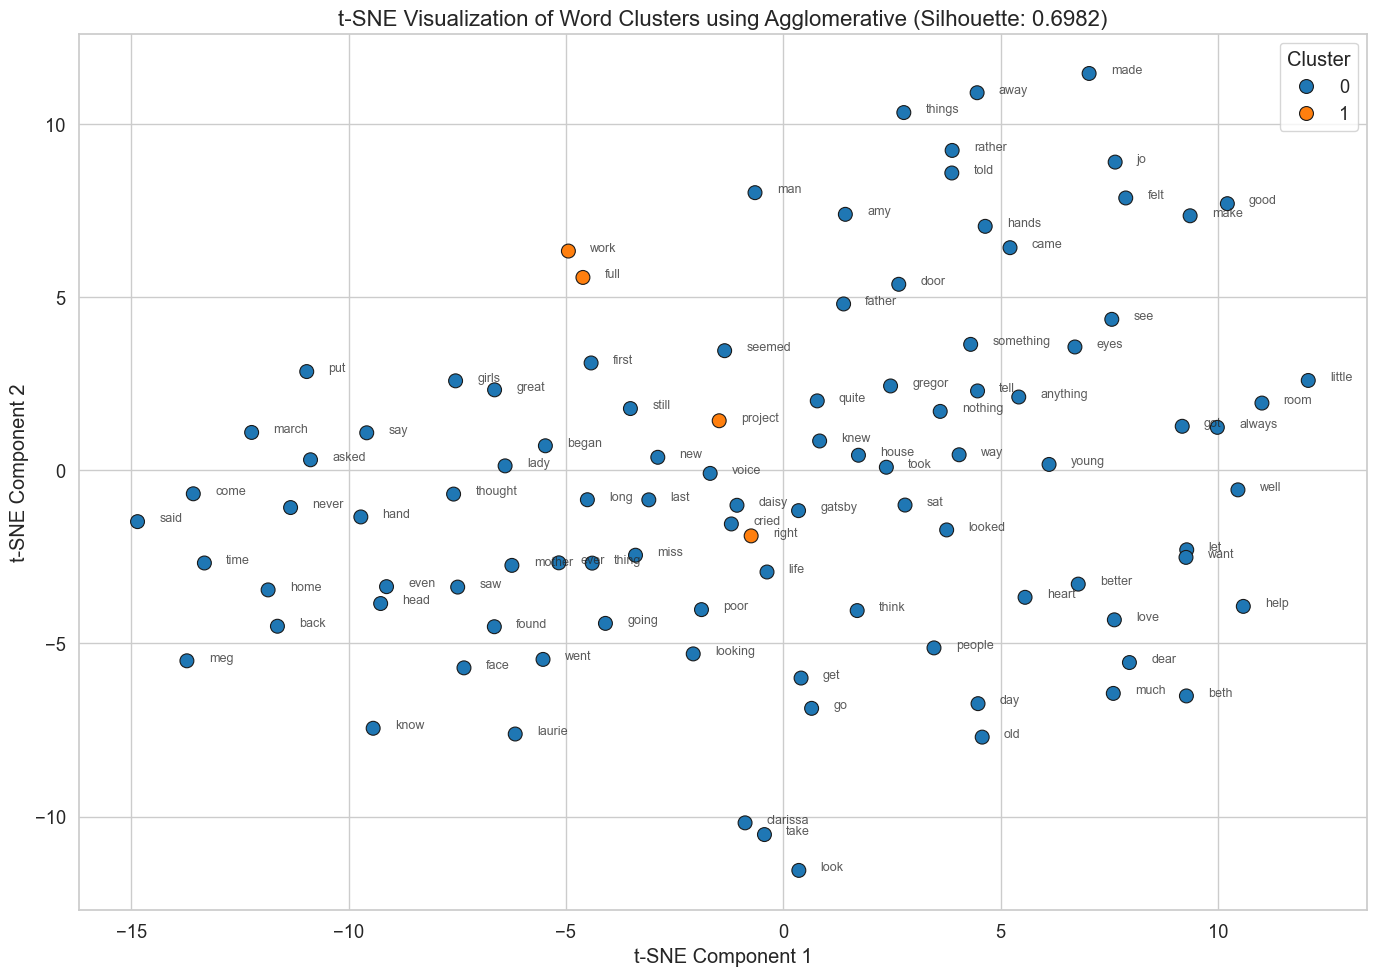

In [20]:
# Reduce similarity matrix to 2D for plotting
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
reduced = tsne.fit_transform(similarity_matrix_optimized)

# Create DataFrame for plotting
df = pd.DataFrame({
    'x': reduced[:, 0],
    'y': reduced[:, 1],
    'label': final_labels,
    'word': L
})

# Set up plot
plt.figure(figsize=(14, 10))
sns.set(style="whitegrid", font_scale=1.2)

palette = sns.color_palette("tab10", len(set(final_labels)))
sns.scatterplot(data=df, x='x', y='y', hue='label', palette=palette, s=100, edgecolor='k')

# Annotate words
for _, row in df.iterrows():
    plt.text(row['x'] + 0.5, row['y'], row['word'], fontsize=9, alpha=0.75)

# Plot titles and labels
plt.title(f"t-SNE Visualization of Word Clusters using {best_model} (Silhouette: {model_scores[best_model]:.4f})", fontsize=16)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Cluster", loc="best")
plt.tight_layout()
plt.show()


In [21]:
# Word2Vec Based Clustering
from gensim.models import KeyedVectors
import gensim.downloader as api

# Load Google's pretrained Word2Vec model (or use another)
word2vec_model = api.load("word2vec-google-news-300")


In [22]:
from sklearn.metrics.pairwise import cosine_distances

def word2vec_distance_matrix(words, model):
    vectors = []
    for word in words:
        if word in model:
            vectors.append(model[word])
        else:
            raise ValueError(f"'{word}' not in Word2Vec model")
    vectors = np.vstack(vectors)
    return cosine_distances(vectors)

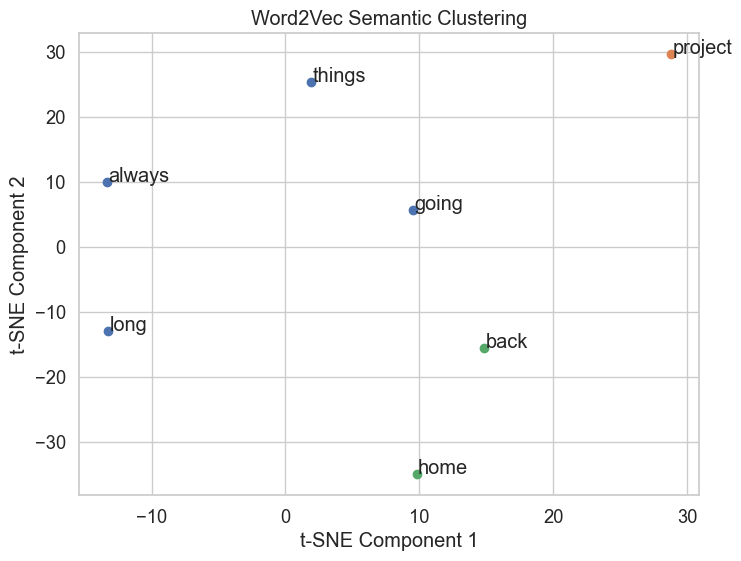

In [23]:
words = ['project', 'things', 'home', 'always', 'going', 'back', 'long']
w2v_distances = word2vec_distance_matrix(words, word2vec_model)

# Cluster
labels = AgglomerativeClustering(n_clusters=3, metric='precomputed', linkage='average').fit_predict(w2v_distances)

# Visualize
tsne = TSNE(metric="precomputed", perplexity=5, init = "random")
embedded = tsne.fit_transform(w2v_distances)

plt.figure(figsize=(8,6))
for i, word in enumerate(words):
    plt.scatter(embedded[i,0], embedded[i,1], c=f"C{labels[i]}", label=word)
    plt.text(embedded[i,0]+0.1, embedded[i,1], word)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Word2Vec Semantic Clustering")
plt.show()

In [24]:
# BERT Model
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')  # Small, fast, effective

words = [word for word in L if word in word2vec_model]
print(f"Using {len(words)} words that are in the Word2Vec model.")

bert_embeddings = model.encode(words)

# Compute distances
bert_distances = cosine_distances(bert_embeddings)



Using 97 words that are in the Word2Vec model.


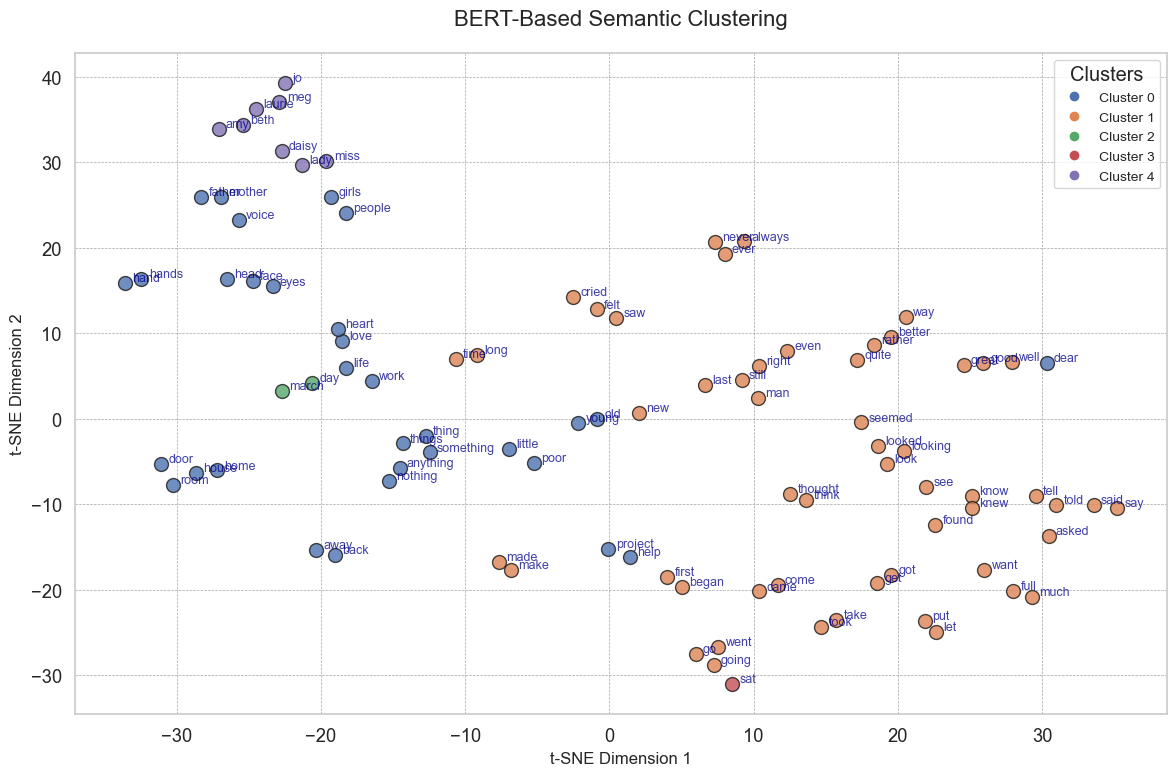

In [25]:
labels = AgglomerativeClustering(n_clusters = 5, metric = 'precomputed', linkage = 'average').fit_predict(bert_distances)

tsne = TSNE(metric = "precomputed", perplexity = 5, init = "random")
embedded = tsne.fit_transform(bert_distances)

plt.figure(figsize = (12, 8))
for i, word in enumerate(words):
    plt.scatter(embedded[i, 0],
                embedded[i, 1], 
                c = f"C{labels[i]}", 
                s = 100,
                edgecolor = "k", 
                alpha = 0.8
               )
    plt.text(embedded[i, 0] + 0.5, 
             embedded[i, 1] + 0.2,
             word,
             fontsize = 9,
             alpha = 0.75, color = "darkblue"
            )
# Title and Axes Labels
plt.title("BERT-Based Semantic Clustering", fontsize=16, pad=20)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)

# Grid for Better Context
plt.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.7)

# Legend Optimization
unique_clusters = np.unique(labels)
handles = [plt.Line2D([], [], marker="o", color=f"C{cluster_id}", label=f"Cluster {cluster_id}", linestyle="None") 
           for cluster_id in unique_clusters]
plt.legend(handles=handles, title="Clusters", loc="best", fontsize=10, frameon=True)

# Finalize and Display Plot
plt.tight_layout()
plt.show()


In [26]:
# Combined clustering
L = ['said', 'jo', 'little', 'meg', 'amy', 'old', 'laurie', 'see', 'go', 'never', 'time', 'thought', 'good', 'came', 'made', 'much', 'come', 'mother', 'know', 'went', 'well', 'beth', 'looked', 'say', 'way', 'got', 'people', 'think', 'away', 'get', 'work', 'young', 'look', 'eyes', 'room', 'asked', 'make', 'something', 'man', 'face', 'day', 'project', 'things', 'home', 'always', 'going', 'back', 'long', 'march', 'felt', 'even', 'first', 'girls', 'gregor', 'let', 'father', 'hand', 'love', 'head', 'seemed', 'tell', 'put', 'door', 'life', 'quite', 'new', 'looking', 'great', 'nothing', 'take', 'house', 'dear', 'took', 'saw', 'clarissa', 'ever', 'lady', 'still', 'help', 'gatsby', 'miss', 'heart', 'knew', 'hands', 'began', 'anything', 'right', 'last', 'better', 'cried', 'rather', 'sat', 'want', 'daisy', 'full', 'thing', 'poor', 'found', 'told', 'voice']

bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Filter valid words for Word2Vec
words = [word for word in L if word in word2vec_model]
print(f"Using {len(words)} words that are in the Word2Vec model.")

# Embeddings
# Word2Vec
w2v_vectors = np.array([word2vec_model[word] for word in words])

# BERT
bert_vectors = bert_model.encode(words)

# Clustering
n_clusters = 3
w2v_labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(w2v_vectors)
bert_labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(bert_vectors)

# t-SNE
w2v_tsne = TSNE(n_components=2, perplexity=5, init='random').fit_transform(w2v_vectors)
bert_tsne = TSNE(n_components=2, perplexity=5, init='random').fit_transform(bert_vectors)

Using 97 words that are in the Word2Vec model.


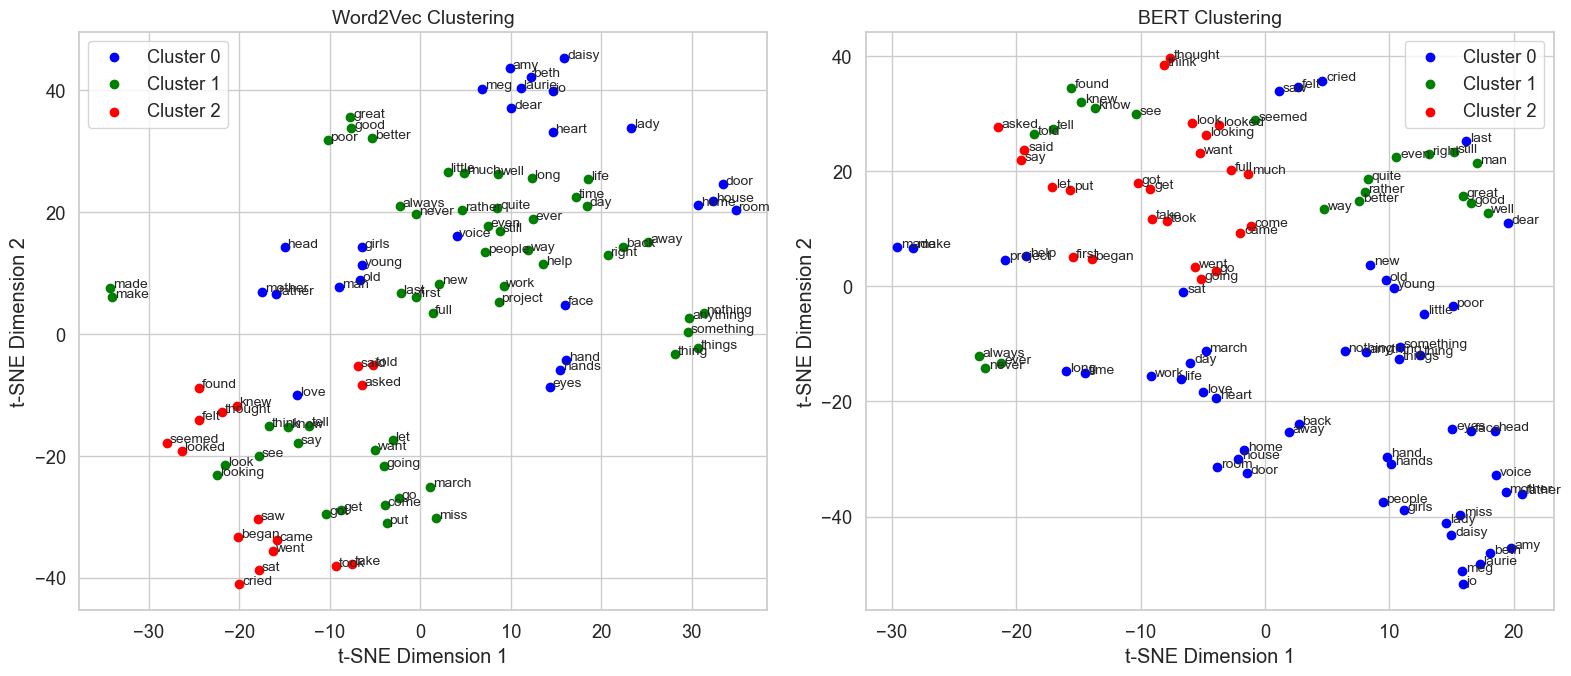

In [27]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
titles = ['Word2Vec Clustering', 'BERT Clustering']
data = [(w2v_tsne, w2v_labels), (bert_tsne, bert_labels)]
colors = ['blue', 'green', 'red']

for ax, (embedding, labels), title in zip(axes, data, titles):
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    
    # Plot each cluster only ONCE in legend
    for cluster_id in np.unique(labels):
        idxs = np.where(labels == cluster_id)[0]
        ax.scatter(embedding[idxs, 0], embedding[idxs, 1], c=colors[cluster_id], label=f'Cluster {cluster_id}')
        for i in idxs:
            ax.text(embedding[i, 0] + 0.3, embedding[i, 1], words[i], fontsize=10)
    
    ax.legend()  # Show only unique cluster labels
    ax.grid(True)

plt.tight_layout()
plt.show()

### 5. Compute Shortest Paths with Dijkstra

In [29]:
def dijkstra(graph, start):
    # Priority queue for selecting the next shortest distance node
    pq = [(0, start)]  # (distance, node)
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    predecessors = {node: None for node in graph}

    while pq:
        current_distance, current_node = heapq.heappop(pq)

        # Process each neighbor of the current node
        for neighbor, weight in graph[current_node]:
            distance = current_distance + weight
            if distance < distances[neighbor]:  # Found a shorter path
                distances[neighbor] = distance
                predecessors[neighbor] = current_node
                heapq.heappush(pq, (distance, neighbor))

    return distances, predecessors

In [30]:
# Example graph where words are nodes & distances (edge weights) are semantic distances
word_graph = {
    'project': [('things', 0.5), ('home', 1.2), ('always', 1.0)],
    'things': [('project', 0.5), ('going', 0.8)],
    'home': [('project', 1.2), ('back', 0.7)],
    'always': [('project', 1.0), ('going', 0.9)],
    'going': [('things', 0.8), ('always', 0.9), ('back', 1.1)],
    'back': [('home', 0.7), ('going', 1.1), ('long', 0.6)],
    'long': [('back', 0.6)]
}

# Compute shortest paths from 'project'
shortest_distances, predecessors = dijkstra(word_graph, 'project')

# Print shortest paths
for node, distance in shortest_distances.items():
    print(f"Shortest distance to {node}: {distance}")

print(f"\nGraph nodes: {list(word_graph.keys())}")
print(f"Graph size matches distance matrix: {len(word_graph)}")

Shortest distance to project: 0
Shortest distance to things: 0.5
Shortest distance to home: 1.2
Shortest distance to always: 1.0
Shortest distance to going: 1.3
Shortest distance to back: 1.9
Shortest distance to long: 2.5

Graph nodes: ['project', 'things', 'home', 'always', 'going', 'back', 'long']
Graph size matches distance matrix: 7


In [31]:
def reconstruct_path(predecessors, start, end):
    path = []
    while end is not None:
        path.append(end)
        end = predecessors[end]
    return path[::-1]  # Reverse the path

# Example: Shortest path from 'project' to 'long'
shortest_path = reconstruct_path(predecessors, 'project', 'long')
print("Shortest path:", " -> ".join(shortest_path))

Shortest path: project -> home -> back -> long


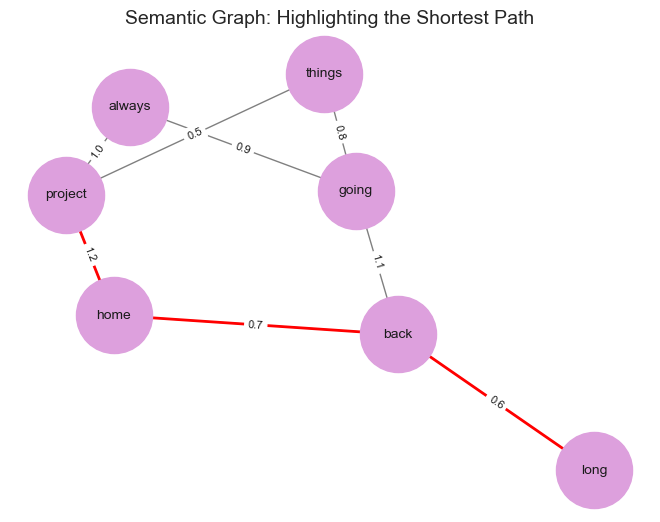

In [32]:
def plot_graph(graph, shortest_path=None):
    G = nx.Graph()
    
    # Add edges to the graph
    for node, neighbors in graph.items():
        for neighbor, weight in neighbors:
            G.add_edge(node, neighbor, weight=weight)
    
    # Compute positions using spring layout
    pos = nx.spring_layout(G, seed=42)
    
    # Draw nodes and edges
    nx.draw(G, pos, with_labels=True, node_color='plum', edge_color='gray', node_size=3000, font_size=10)
    
    # Highlight shortest path in red
    if shortest_path:
        path_edges = list(zip(shortest_path, shortest_path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)

    # Draw edge weights
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    
    # Add title to the plot
    plt.title("Semantic Graph: Highlighting the Shortest Path", fontsize=14)
    plt.show()

# Visualize the graph and highlight the shortest path
plot_graph(word_graph, shortest_path)

### 6. Repeat Clustering with Shortestest Distances
#### For the sample list of words

In [34]:
def compute_shortest_path_matrix(graph, words):
    n = len(words)
    distance_matrix = np.zeros((n, n))

    for i, word1 in enumerate(words):
        shortest_distances, _ = dijkstra(graph, word1)  # Compute all shortest paths from word1
        for j, word2 in enumerate(words):
            distance_matrix[i][j] = shortest_distances.get(word2, float('inf'))  # If no path, set to infinity

    return distance_matrix

In [35]:
# Compute new distance matrix based on shortest paths
shortest_path_matrix = compute_shortest_path_matrix(word_graph, list(word_graph.keys()))

# Perform clustering
n_clusters = 3  # Changing parameter
new_labels = AgglomerativeClustering(n_clusters=n_clusters, metric="precomputed", linkage="average").fit_predict(shortest_path_matrix)


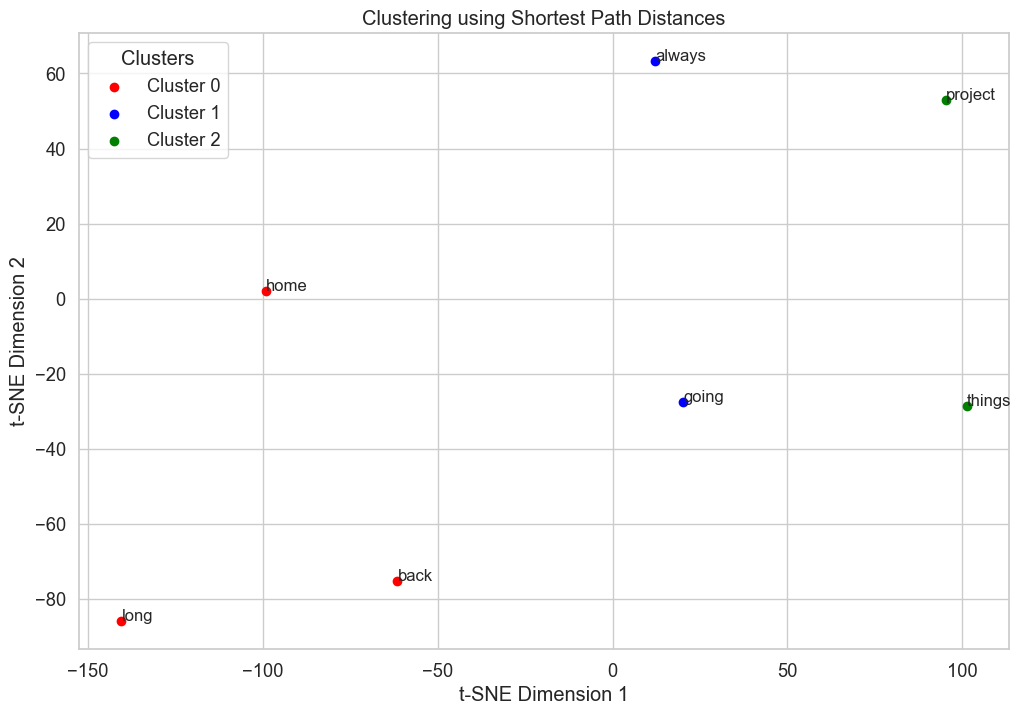

In [36]:
# Apply t-SNE for dimensionality reduction
tsne = TSNE(metric="precomputed", perplexity=5, random_state=42, init="random")
embedded = tsne.fit_transform(shortest_path_matrix)

# Define cluster colors
colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'brown']  
cluster_labels = np.unique(new_labels)

plt.figure(figsize=(12, 8))
for cluster in cluster_labels:
    indices = np.where(new_labels == cluster)
    plt.scatter(embedded[indices, 0], embedded[indices, 1], c=colors[cluster], label=f'Cluster {cluster}')

# Add word labels
for i, word in enumerate(word_graph.keys()):
    plt.text(embedded[i, 0]+0.1, embedded[i, 1], word, fontsize=12)

# Formatting
plt.title("Clustering using Shortest Path Distances")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Clusters", loc='best')
plt.show()

In [37]:
cluster_summary = {cluster: [] for cluster in cluster_labels}
for word, label in zip(word_graph.keys(), new_labels):
    cluster_summary[label].append(word)
for cluster, words in cluster_summary.items():
    print(f"Cluster {cluster}: {', '.join(words)}")

Cluster 0: home, back, long
Cluster 1: always, going
Cluster 2: project, things


#### For the word list L

In [39]:
# Build a graph from the full similarity matrix
def build_word_graph_from_matrix(similarity_matrix, word_list):
    graph = {word: [] for word in word_list}
    for i, word1 in enumerate(word_list):
        for j, word2 in enumerate(word_list):
            if i != j and similarity_matrix[i][j] > 0:
                graph[word1].append((word2, 1 / similarity_matrix[i][j]))  # Invert to make high co-occurrence = low distance
    return graph

# Build the full graph using L
word_graph_full = build_word_graph_from_matrix(similarity_matrix_optimized, L)

In [40]:
# Compute shortest path matrix for all words
shortest_path_matrix_full = compute_shortest_path_matrix(word_graph_full, L)

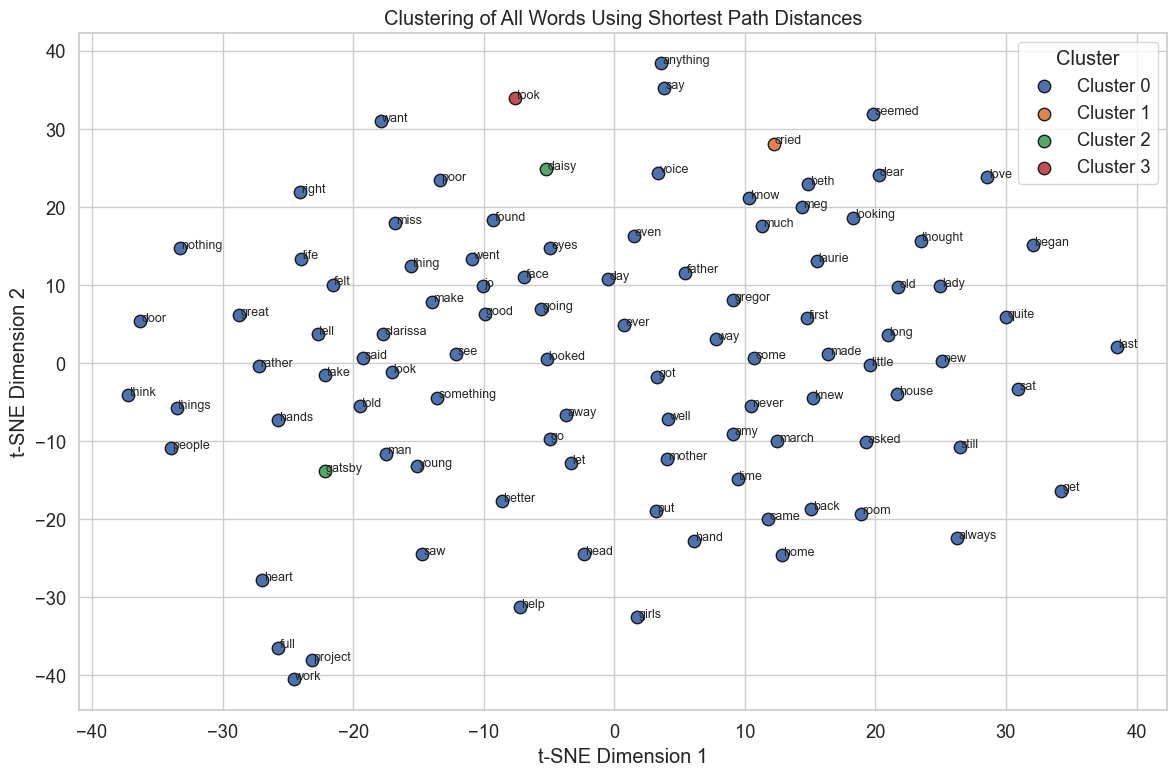

In [41]:
# Perform clustering
n_clusters = 4 # changing parameter
labels_full = AgglomerativeClustering(n_clusters=n_clusters, metric="precomputed", linkage="average").fit_predict(shortest_path_matrix_full)

# Apply t-SNE
tsne = TSNE(metric="precomputed", perplexity=10, random_state=42, init="random")
embedded = tsne.fit_transform(shortest_path_matrix_full)

# Plot with word labels
plt.figure(figsize=(12, 8))
for cluster in np.unique(labels_full):
    indices = np.where(labels_full == cluster)
    plt.scatter(embedded[indices, 0], embedded[indices, 1], label=f'Cluster {cluster}', s=80, edgecolor='k')

# Label words
for i, word in enumerate(L):
    plt.text(embedded[i, 0] + 0.1, embedded[i, 1], word, fontsize=9)

plt.title("Clustering of All Words Using Shortest Path Distances")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Cluster", loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()